In [1]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names, plot_param_sweep

%matplotlib inline
%load_ext autoreload
%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

In [2]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

../models/linear_regression/nanogpt_softmax_test/config.yaml
../models/linear_regression/dabb65f6-7e9b-4b32-b796-2a5af901efd2/config.yaml
../models/linear_regression/pretrained/config.yaml
3 3


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
2,pretrained,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_pretrained
1,dabb65f6-7e9b-4b32-b796-2a5af901efd2,linear_regression,Transformer,,-1,-1,5,12,8,linear_regression_toy
0,nanogpt_softmax_test,linear_regression,nanogpt_softmax_test,,-1,-1,20,12,8,nanogpt_softmax_test


In [3]:
task = "linear_regression"
#task = "sparse_linear_regression"
#task = "decision_tree"
#task = "relu_2nn_regression"

run_id = "nanogpt_softmax_test"  # if you train more models, replace with the run_id from the table above

run_path = os.path.join(run_dir, task, run_id)
recompute_metrics = True

if recompute_metrics:
    results = get_run_metrics(run_path)  # these are normally precomputed at the end of training

import json
with open("results.json", "w") as f:
    json.dump(results, f, indent=4)


../models/linear_regression/nanogpt_softmax_test/config.yaml
number of parameters: 9.48M
odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.attn.c_proj.bias', '_backbone.transformer.h.1.ln_2

RuntimeError: Error(s) in loading state_dict for NanoGPTTransformerModel:
	Missing key(s) in state_dict: "_backbone.transformer.h.0.attn.causal_mask", "_backbone.transformer.h.1.attn.causal_mask", "_backbone.transformer.h.2.attn.causal_mask", "_backbone.transformer.h.3.attn.causal_mask", "_backbone.transformer.h.4.attn.causal_mask", "_backbone.transformer.h.5.attn.causal_mask", "_backbone.transformer.h.6.attn.causal_mask", "_backbone.transformer.h.7.attn.causal_mask", "_backbone.transformer.h.8.attn.causal_mask", "_backbone.transformer.h.9.attn.causal_mask", "_backbone.transformer.h.10.attn.causal_mask", "_backbone.transformer.h.11.attn.causal_mask". 
	size mismatch for _backbone.transformer.wpe.weight: copying a param with shape torch.Size([82, 256]) from checkpoint, the shape in current model is torch.Size([202, 256]).

In [ ]:
state = torch.load("../models/linear_regression/nanogpt_softmax_test/state.pt", map_location=torch.device('cpu'))

In [ ]:
state['model_state_dict'].keys()

odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.attn.c_proj.bias', '_backbone.transformer.h.1.ln_2.weight', '_backbone.transformer.h.1.ln_2.bias', '_backbone.transformer.h.1.mlp.c_fc.weig

# Interactive setup

We will now directly load the model and measure its in-context learning ability on a batch of random inputs. (In the paper we average over multiple such batches to obtain better estimates.)

In [ ]:
from samplers import get_data_sampler
from tasks import get_task_sampler

In [ ]:
model, conf = get_model_from_run(run_path)

n_dims = conf.model.n_dims
batch_size = conf.training.batch_size

data_sampler = get_data_sampler(conf.training.data, n_dims)
task_sampler = get_task_sampler(
    conf.training.task,
    n_dims,
    batch_size,
    **conf.training.task_kwargs
)

../models/linear_regression/pretrained/config.yaml


In [ ]:
task = task_sampler()
xs = data_sampler.sample_xs(b_size=batch_size, n_points=conf.training.curriculum.points.end)
ys = task.evaluate(xs)

In [ ]:
with torch.no_grad():
    pred = model(xs, ys)

In [ ]:
# Let's inspect a single example from the batch
b_idx = 0
n_points = conf.training.curriculum.points.end
# The last point is the query, the rest is context
n_context = n_points - 1

print(f"--- Task: {conf.training.task} ---")
print(f"--- Ground Truth W ---\n{task.w[b_idx].numpy()}")
print("\n--- Context ---")
for i in range(n_context):
    x = xs[b_idx, i, 0, :].numpy()
    y = ys[b_idx, i, :].numpy()
    print(f"x_{i}: {x}, y_{i}: {y}")

print("\n--- Query ---")
x_query = xs[b_idx, n_context, 0, :].numpy()
print(f"x_q: {x_query}")

print("\n--- True Response ---")
y_true = ys[b_idx, n_context, :].numpy()
print(f"y_q: {y_true}")

print("\n--- Model Response ---")
y_pred = pred[b_idx, n_context-1, :].numpy()
print(f"y_pred: {y_pred}")

--- Task: linear_regression ---


AttributeError: 'LinearRegression' object has no attribute 'w'

In [ ]:
metric = task.get_metric()
loss = metric(pred, ys).numpy()

sparsity = conf.training.task_kwargs.sparsity if "sparsity" in conf.training.task_kwargs else None
baseline = {
    "linear_regression": n_dims,
    "sparse_linear_regression": sparsity,
    "relu_2nn_regression": n_dims,
    "decision_tree": 1,
}[conf.training.task]

plt.plot(loss[b_idx], lw=2, label=f"Transformer (example {b_idx})")
plt.axhline(baseline, ls="--", color="gray", label="zero estimator")
plt.xlabel("# in-context examples")
plt.ylabel("squared error")
plt.legend()
plt.show()

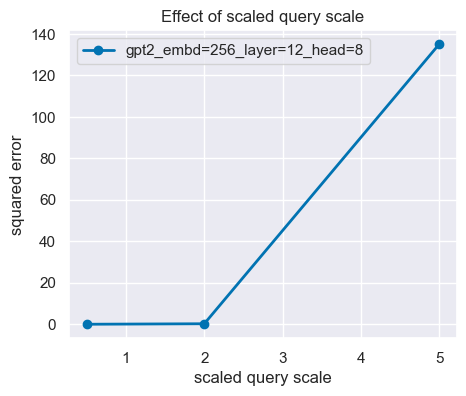

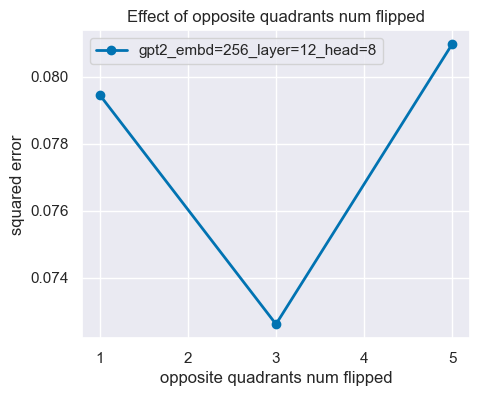

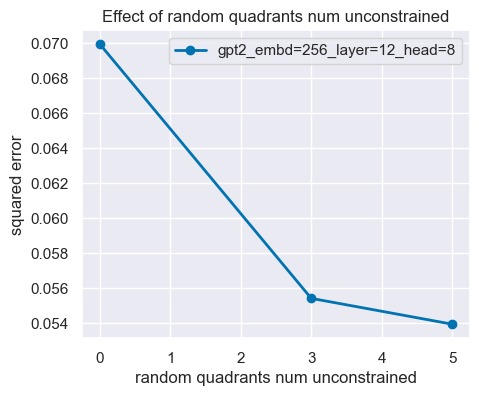

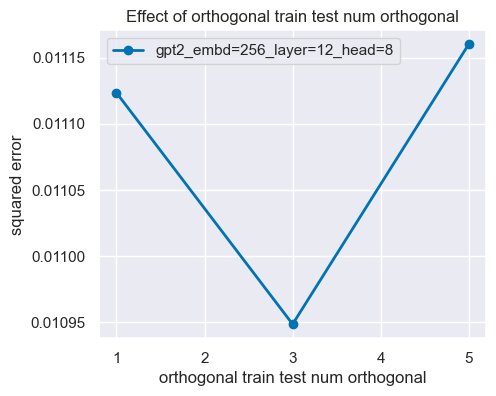

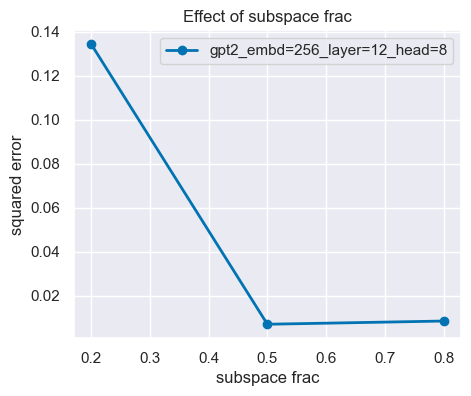

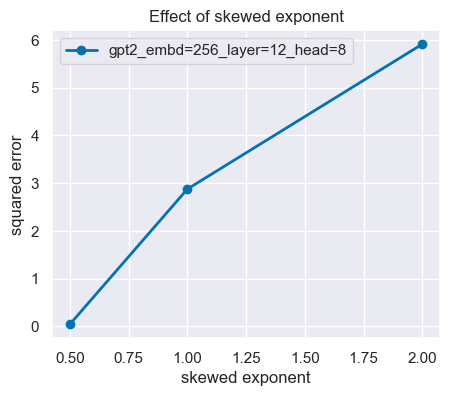

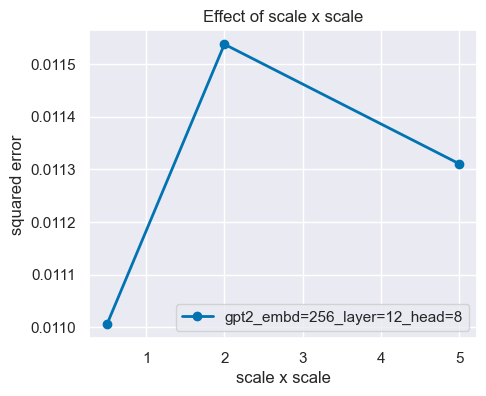

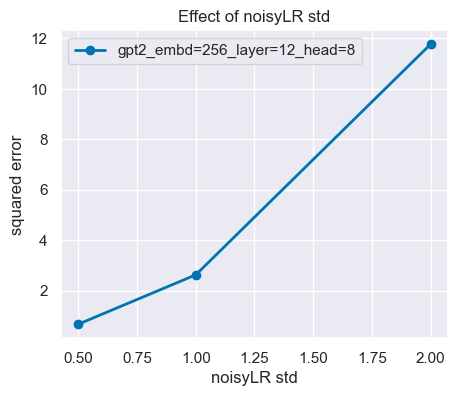

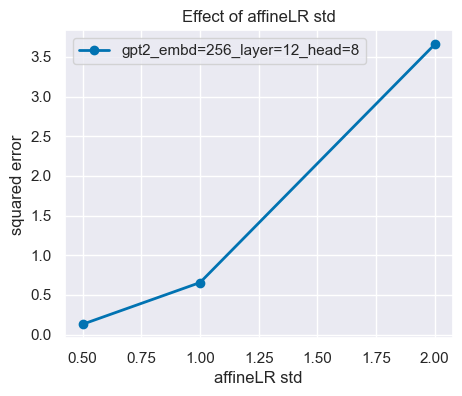

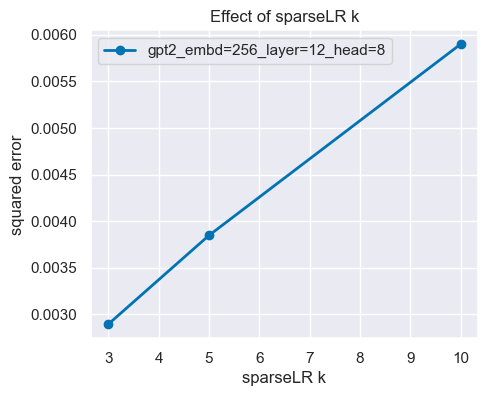

In [ ]:
import json

with open("results.json", "r") as f:
    results = json.load(f)

figs = plot_param_sweep(results)
for fig in figs:
    plt.show()